# Step 1

In [ ]:
"""
STEP 1 — Load the full ICIO table
===================================
Output: df_icio (raw), Z (intermediate-use only, all countries)
"""

import pandas as pd

FINAL_DEMAND = {"HFCE", "NPISH", "GGFC", "GFCF", "INVNT", "DPABR"}

## 
df_icio = pd.read_csv("2022.csv", index_col=0)

# Keep only intermediate-use columns (drop final demand and output)
intermediate_cols = [
    c for c in df_icio.columns
    if not any(c.endswith(fd) for fd in FINAL_DEMAND) and c != "OUT"
]

# Keep only country-sector rows (drop any aggregate rows if present)
intermediate_rows = [
    r for r in df_icio.index
    if "_" in r  # all country-sector codes look like "ITA_C28"
]

Z = df_icio.loc[intermediate_rows, intermediate_cols].copy()

print(f"Full intermediate-use matrix: {Z.shape}")
print(f"Example row indices:    {list(Z.index[:3])}")
print(f"Example col indices:    {list(Z.columns[:3])}")
print(f"Countries in rows:      {len(set(r.split('_')[0] for r in Z.index))}")
print(f"Sectors per country:    {len(set(r.split('_')[1] for r in Z.index))}")

Full intermediate-use matrix: (4250, 4250)
Example row indices:    ['AGO_A01', 'AGO_A02', 'AGO_A03']
Example col indices:    ['AGO_A01', 'AGO_A02', 'AGO_A03']
Countries in rows:      85
Sectors per country:    50


# Step 2

In [3]:
"""
STEP 2 — Build the global directed weighted graph
===================================================
Depends on: Z  (from Step 1)

Each node  = "COUNTRY_SECTOR"  e.g. "ITA_C28"
Each edge  i → j = sector i supplies intermediate inputs to sector j
Weight     = flow value in million USD

Threshold filters noise (tiny flows slow down centrality with no insight).
Adjust THRESHOLD if you want a denser or sparser graph.

Output: G
"""

import networkx as nx

THRESHOLD = 50  # million USD — raise this if graph is too large / slow

G = nx.DiGraph()
G.add_nodes_from(Z.index)

for src in Z.index:
    row_vals = Z.loc[src]
    for dst, val in row_vals.items():
        if val > THRESHOLD:
            G.add_edge(src, dst, weight=float(val))

print(f"Nodes : {G.number_of_nodes():,}")
print(f"Edges : {G.number_of_edges():,}")

# Quick sanity check — how many Italian nodes?
ita_nodes = [n for n in G.nodes if n.startswith("ITA_")]
print(f"Italian nodes in graph: {len(ita_nodes)}")
print(f"Example: {ita_nodes[:5]}")

Nodes : 4,250
Edges : 95,097
Italian nodes in graph: 50
Example: ['ITA_A01', 'ITA_A02', 'ITA_A03', 'ITA_B05', 'ITA_B06']


# Step 3

In [4]:
"""
STEP 3 — Compute centrality measures on the full global graph
==============================================================
Depends on: G  (from Step 2)

Three measures, each capturing something different:

  in_strength   = total value of inputs received from all countries
                  → how much the sector depends on the global supply chain

  out_strength  = total value of outputs sent to all countries
                  → how much other sectors depend on this one

  pagerank      = weight-aware authority score
                  → a sector scores high if it is fed by other high-scoring
                    sectors; good proxy for systemic importance

  betweenness   [OPTIONAL / SLOW on large graphs]
                = fraction of shortest supply paths passing through a node
                  → pure bottleneck / broker measure
                  Use k=500 for a fast approximation (±5% error, seconds not minutes)

Output: centrality_df  (one row per global node)
        ita_centrality (filtered to Italy only)
"""

import pandas as pd
import networkx as nx

# --- Always fast ---
in_strength  = {n: sum(d["weight"] for _, _, d in G.in_edges(n,  data=True)) for n in G.nodes}
out_strength = {n: sum(d["weight"] for _, _, d in G.out_edges(n, data=True)) for n in G.nodes}
pagerank     = nx.pagerank(G, weight="weight")

# --- Betweenness: choose ONE of the two options below ---

# Option A — exact (slow on large graphs, fine on domestic-only)
# betweenness = nx.betweenness_centrality(G, weight="weight", normalized=True)

# Option B — approximate (k random pivots, good enough for ranking purposes)
betweenness = nx.betweenness_centrality(G, weight="weight", normalized=True, k=300)

print("Centrality computed.")

# Build dataframe
centrality_df = pd.DataFrame({
    "node":         list(G.nodes),
    "country":      [n.split("_")[0] for n in G.nodes],
    "sector":       [n.split("_")[1] for n in G.nodes],
    "in_strength":  [in_strength[n]  for n in G.nodes],
    "out_strength": [out_strength[n] for n in G.nodes],
    "pagerank":     [pagerank[n]     for n in G.nodes],
    "betweenness":  [betweenness[n]  for n in G.nodes],
})
centrality_df["total_strength"] = centrality_df["in_strength"] + centrality_df["out_strength"]

# Filter to Italy
ita_centrality = centrality_df[centrality_df["country"] == "ITA"].copy().reset_index(drop=True)

print(f"\nGlobal centrality_df shape: {centrality_df.shape}")
print(f"Italian rows: {len(ita_centrality)}")
print("\nTop 5 Italian sectors by PageRank (global ranking):")
print(ita_centrality.nlargest(5, "pagerank")[["sector","pagerank","betweenness","total_strength"]])

Centrality computed.

Global centrality_df shape: (4250, 8)
Italian rows: 50

Top 5 Italian sectors by PageRank (global ranking):
    sector  pagerank  betweenness  total_strength
46       Q  0.002051     0.000117      89997.2288
29       F  0.001822     0.002636     296005.7557
8   C10T12  0.001809     0.003263     183939.4734
30       G  0.001543     0.004648     440129.8103
9   C13T15  0.001276     0.003630      83292.1701


## Per questo grafico ho preparato un HTML interattivo!!!
--> just go to the directory viz and then tipe open viz1.html

Top 10 partners: ['ROW', 'DEU', 'FRA', 'CN1', 'USA', 'ESP', 'IRL', 'RUS', 'CHE', 'GBR']
Edges after top-5% filter: 84
Saved fig0_network_spine.png


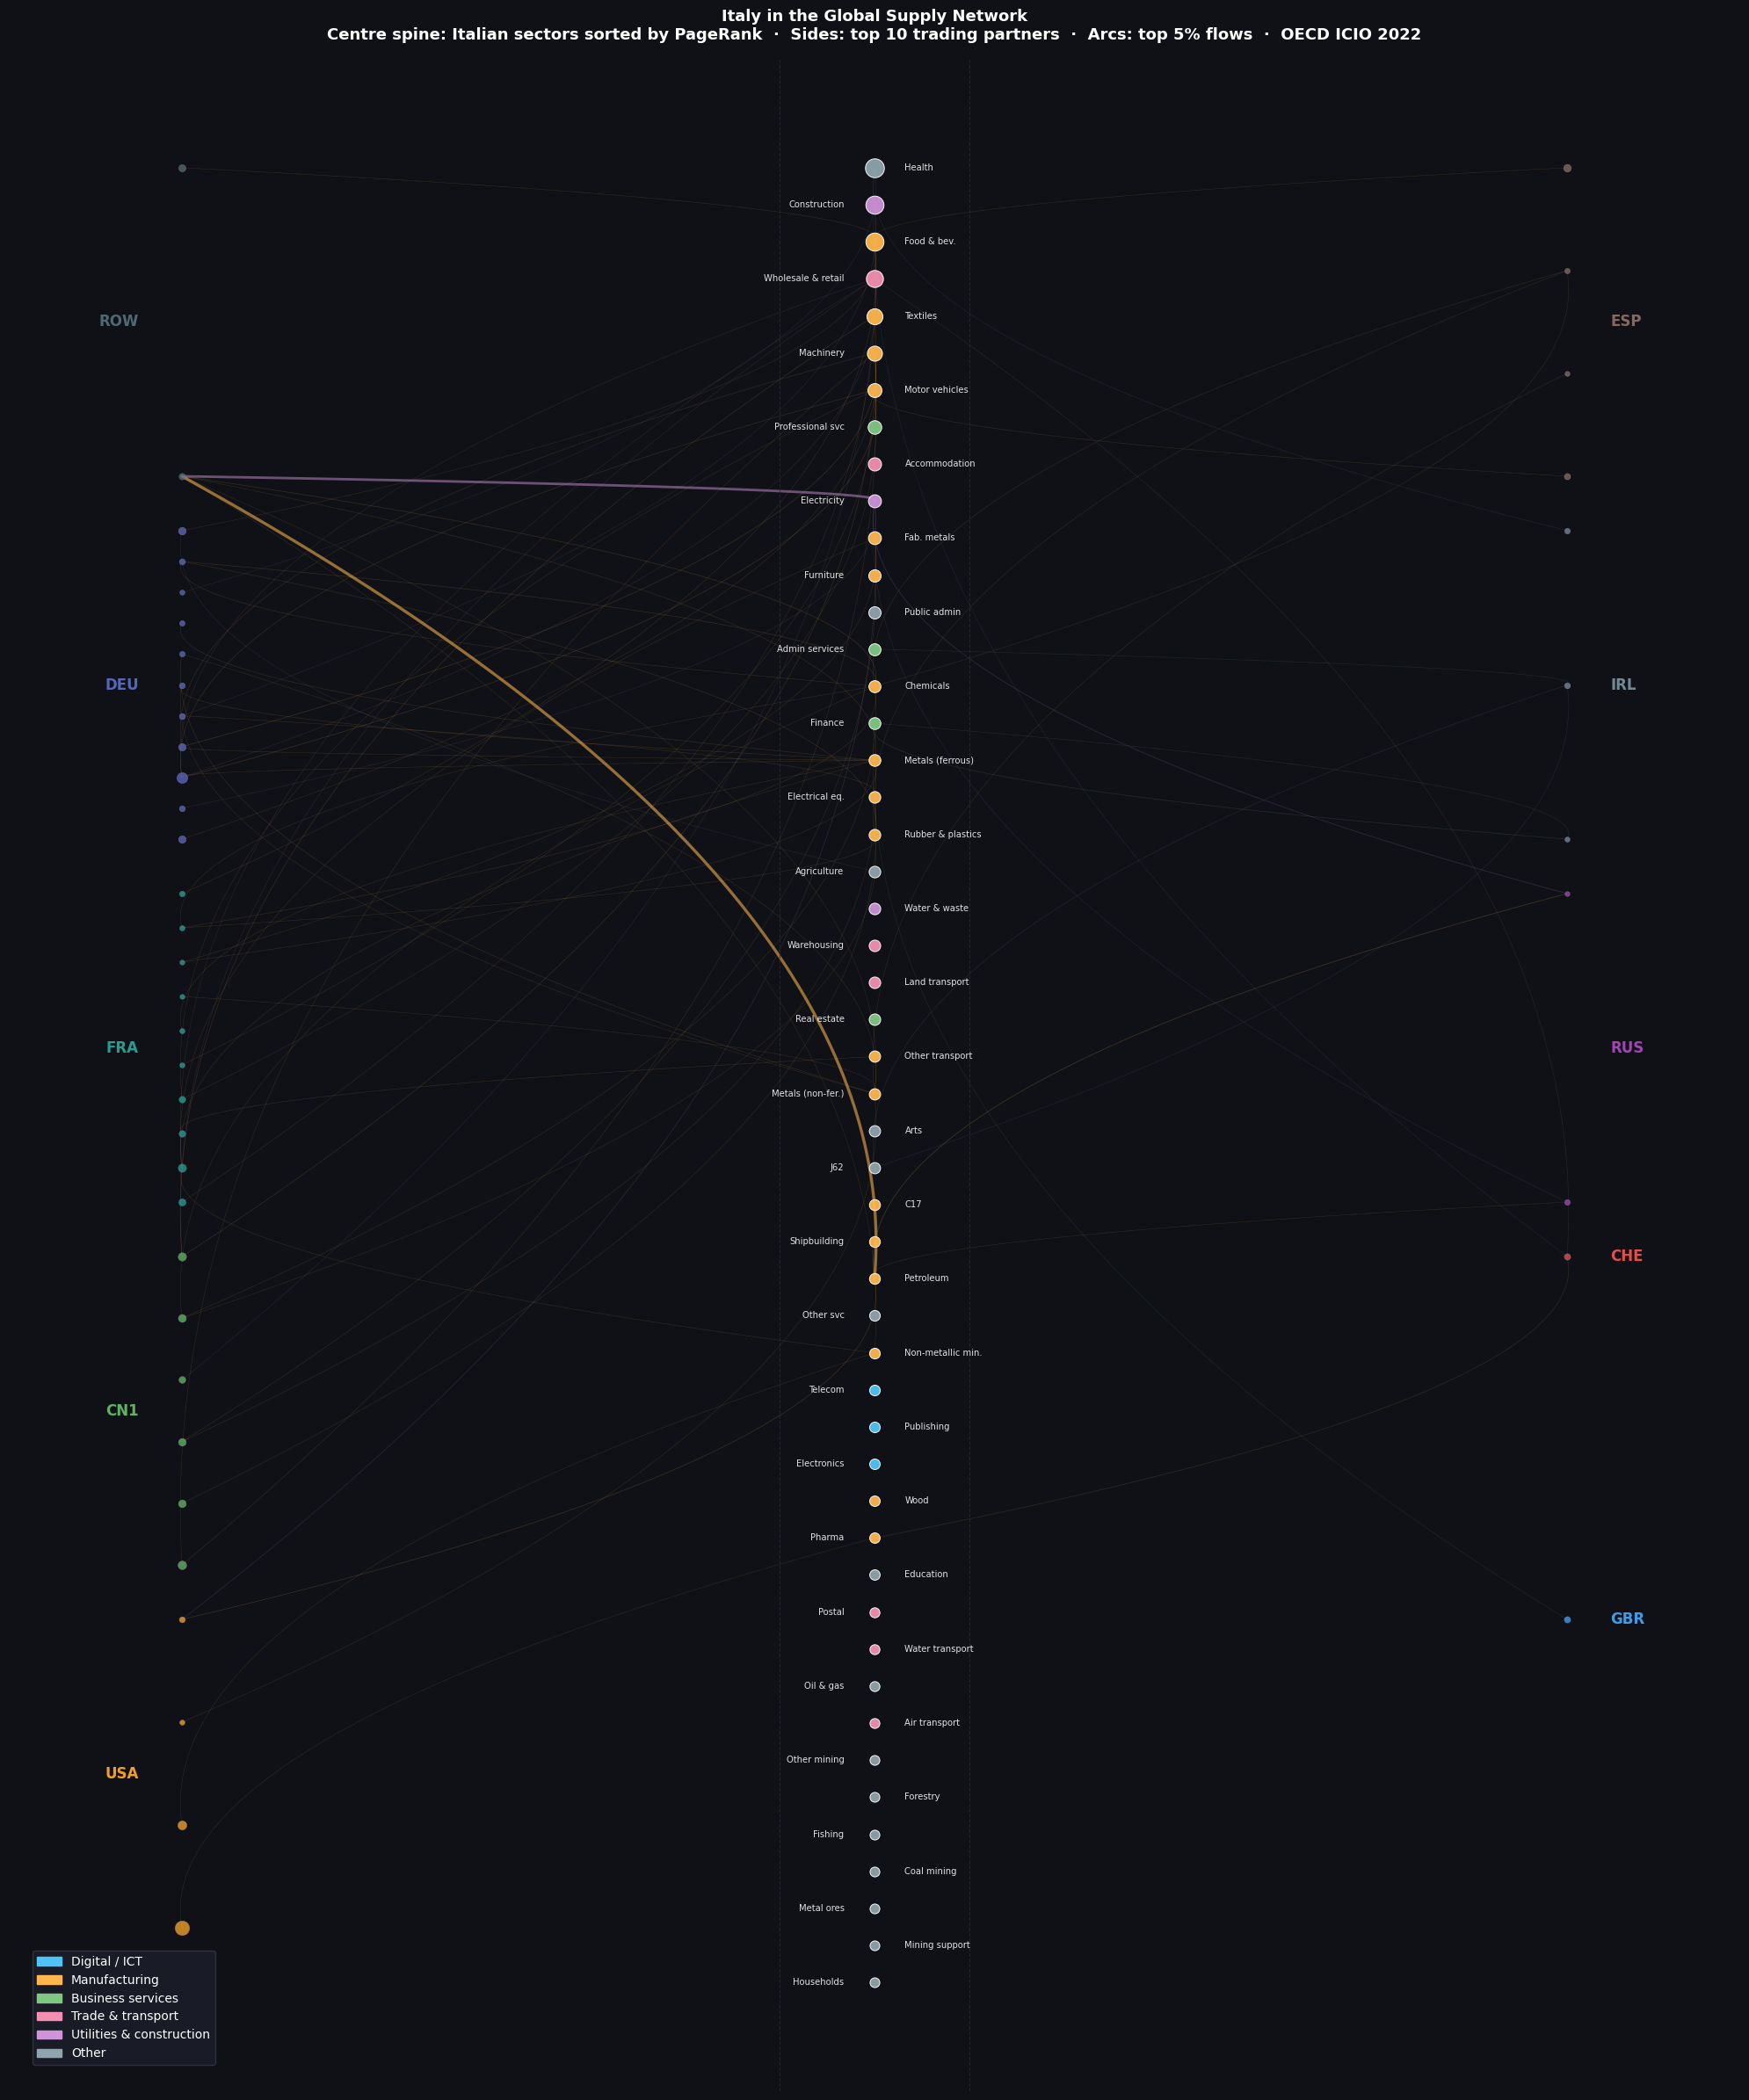

In [6]:
"""
STEP 3b (v2) — Network visualisation: vertical spine layout
=============================================================
Depends on: G, pagerank, centrality_df  (from Step 3)

Layout:
  - Italy sectors: vertical column in the centre, sorted by PageRank
  - Top 10 partner countries: split left/right, sorted by total flow with Italy
  - Edges: only top 5% strongest flows, drawn as bezier arcs
  - Node size: PageRank
  - Node colour: Italy = sector type, partners = country colour
  - Edge colour: inherits from the Italian sector it connects to
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# =============================================================================
# 1. IDENTIFY TOP 10 PARTNER COUNTRIES
# =============================================================================
ita_nodes = [n for n in G.nodes if n.startswith("ITA_")]

country_flow = {}
for u, v, d in G.edges(data=True):
    u_country = u.split("_")[0]
    v_country = v.split("_")[0]
    if (u_country == "ITA") == (v_country == "ITA"):
        continue   # skip purely domestic or purely foreign edges
    foreign = v_country if u_country == "ITA" else u_country
    country_flow[foreign] = country_flow.get(foreign, 0) + d["weight"]

top10_countries = sorted(country_flow, key=country_flow.get, reverse=True)[:10]
print(f"Top 10 partners: {top10_countries}")

# =============================================================================
# 2. TOP 5% EDGES (Italy ↔ top10 countries only)
# =============================================================================
candidate_edges = [
    (u, v, d["weight"]) for u, v, d in G.edges(data=True)
    if (u.startswith("ITA_") and v.split("_")[0] in top10_countries) or
       (v.startswith("ITA_") and u.split("_")[0] in top10_countries)
]

weights   = [e[2] for e in candidate_edges]
threshold = np.percentile(weights, 95)
top_edges = [(u, v, w) for u, v, w in candidate_edges if w >= threshold]
print(f"Edges after top-5% filter: {len(top_edges)}")

# =============================================================================
# 3. LABELS AND COLOURS
# =============================================================================
SECTOR_LABELS = {
    "A01": "Agriculture",       "A02": "Forestry",
    "A03": "Fishing",           "B05": "Coal mining",
    "B06": "Oil & gas",         "B07": "Metal ores",
    "B08": "Other mining",      "B09": "Mining support",
    "C10T12": "Food & bev.",    "C13T15": "Textiles",
    "C16": "Wood",              "C17_18": "Paper",
    "C19": "Petroleum",         "C20": "Chemicals",
    "C21": "Pharma",            "C22": "Rubber & plastics",
    "C23": "Non-metallic min.", "C24A": "Metals (ferrous)",
    "C24B": "Metals (non-fer.)","C25": "Fab. metals",
    "C26": "Electronics",       "C27": "Electrical eq.",
    "C28": "Machinery",         "C29": "Motor vehicles",
    "C301": "Shipbuilding",     "C302T309": "Other transport",
    "C31T33": "Furniture",      "D": "Electricity",
    "E": "Water & waste",       "F": "Construction",
    "G": "Wholesale & retail",  "H49": "Land transport",
    "H50": "Water transport",   "H51": "Air transport",
    "H52": "Warehousing",       "H53": "Postal",
    "I": "Accommodation",       "J58T60": "Publishing",
    "J61": "Telecom",           "J62_63": "IT services",
    "K": "Finance",             "L": "Real estate",
    "M": "Professional svc",    "N": "Admin services",
    "O": "Public admin",        "P": "Education",
    "Q": "Health",              "R": "Arts",
    "S": "Other svc",           "T": "Households",
}

def ita_sector_color(sector_code):
    s = sector_code
    if s in ["J58T60","J61","J62_63","C26"]:         return "#4FC3F7"
    if s.startswith("C"):                             return "#FFB74D"
    if s in ["K","M","N","L"]:                        return "#81C784"
    if s in ["G","H49","H50","H51","H52","H53","I"]:  return "#F48FB1"
    if s in ["D","E","F"]:                            return "#CE93D8"
    return "#90A4AE"

# =============================================================================
# 4. ASSIGN POSITIONS
# =============================================================================
pr     = pagerank
max_pr = max(pr.values())

# Italian spine: sorted top→bottom by PageRank
ita_sorted = sorted(ita_nodes, key=lambda n: pr.get(n, 0), reverse=True)
n_ita      = len(ita_sorted)
Y_MAX, Y_MIN = 1.0, -1.0
X_ITA        = 0.0
ita_y        = np.linspace(Y_MAX, Y_MIN, n_ita)
ita_pos      = {node: (X_ITA, ita_y[i]) for i, node in enumerate(ita_sorted)}

# Partner sides
left_countries  = top10_countries[:5]
right_countries = top10_countries[5:]
X_LEFT, X_RIGHT = -1.6, 1.6

def foreign_positions(country_list, x_base):
    """Distribute each country's nodes vertically, grouped with a small gap."""
    pos    = {}
    n_c    = len(country_list)
    # Divide vertical space evenly among countries
    band   = (Y_MAX - Y_MIN) / n_c
    for ci, country in enumerate(country_list):
        nodes = sorted([
            n for n in G.nodes
            if n.startswith(f"{country}_") and
            any(n in (u, v) for u, v, _ in top_edges)
        ])
        if not nodes:
            continue
        y_top = Y_MAX - ci * band
        y_bot = y_top - band * 0.85   # small gap between countries
        ys    = np.linspace(y_top, y_bot, len(nodes))
        for node, y in zip(nodes, ys):
            pos[node] = (x_base, y)
    return pos

left_pos  = foreign_positions(left_countries,  X_LEFT)
right_pos = foreign_positions(right_countries, X_RIGHT)
all_pos   = {**ita_pos, **left_pos, **right_pos}

# =============================================================================
# 5. DRAW
# =============================================================================
fig, ax = plt.subplots(figsize=(20, 24), facecolor="#0f1117")
ax.set_facecolor("#0f1117")
ax.axis("off")

max_w = max(w for _, _, w in top_edges)

# ── Bezier arc helper ────────────────────────────────────────────────────────
def draw_arc(ax, p0, p1, color, alpha, lw):
    x0, y0 = p0
    x1, y1 = p1
    # Bulge outward from the spine
    bulge = 0.55 * abs(x1 - x0)
    cx    = (x0 + x1) / 2 + (bulge if x1 > x0 else -bulge)
    cy    = (y0 + y1) / 2
    t     = np.linspace(0, 1, 80)
    bx    = (1-t)**2*x0 + 2*(1-t)*t*cx + t**2*x1
    by    = (1-t)**2*y0 + 2*(1-t)*t*cy + t**2*y1
    ax.plot(bx, by, color=color, alpha=alpha, lw=lw,
            solid_capstyle="round", zorder=1)

# ── Edges ────────────────────────────────────────────────────────────────────
for u, v, w in top_edges:
    if u not in all_pos or v not in all_pos:
        continue
    ita_node = u if u.startswith("ITA_") else v
    color    = ita_sector_color(ita_node.split("_")[1])
    alpha    = 0.12 + 0.45 * (w / max_w)
    lw       = 0.4  + 2.0  * (w / max_w)
    draw_arc(ax, all_pos[u], all_pos[v], color=color, alpha=alpha, lw=lw)

# ── Foreign nodes ────────────────────────────────────────────────────────────
COUNTRY_COLORS = {c: col for c, col in zip(top10_countries, [
    "#546E7A","#5C6BC0","#26A69A","#66BB6A","#FFA726",
    "#8D6E63","#78909C","#AB47BC","#EF5350","#42A5F5",
])}

for node, (x, y) in {**left_pos, **right_pos}.items():
    country = node.split("_")[0]
    size    = 15 + (pr.get(node, 0) / max_pr) * 200
    ax.scatter(x, y, s=size, c=COUNTRY_COLORS.get(country, "#555566"),
               edgecolors="#888899", linewidths=0.3, zorder=3, alpha=0.75)

# ── Italian nodes ────────────────────────────────────────────────────────────
for node in ita_sorted:
    x, y  = ita_pos[node]
    size  = 60 + (pr.get(node, 0) / max_pr) * 1400
    color = ita_sector_color(node.split("_")[1])
    ax.scatter(x, y, s=size, c=color,
               edgecolors="white", linewidths=0.7, zorder=5, alpha=0.95)

# ── Italian labels: alternate left/right of spine ────────────────────────────
for i, node in enumerate(ita_sorted):
    x, y   = ita_pos[node]
    label  = SECTOR_LABELS.get(node.split("_")[1], node.split("_")[1])
    if i % 2 == 0:
        ax.text(x + 0.07, y, label, fontsize=7.2, color="white",
                va="center", ha="left", alpha=0.88)
    else:
        ax.text(x - 0.07, y, label, fontsize=7.2, color="white",
                va="center", ha="right", alpha=0.88)

# ── Country labels ────────────────────────────────────────────────────────────
def country_label_y(pos_dict, country):
    ys = [pos_dict[n][1] for n in pos_dict if n.startswith(f"{country}_")]
    return np.mean(ys) if ys else 0

for country in left_countries:
    y = country_label_y(left_pos, country)
    ax.text(X_LEFT - 0.1, y, country, fontsize=12, color=COUNTRY_COLORS[country],
            fontweight="bold", va="center", ha="right", alpha=0.95)

for country in right_countries:
    y = country_label_y(right_pos, country)
    ax.text(X_RIGHT + 0.1, y, country, fontsize=12, color=COUNTRY_COLORS[country],
            fontweight="bold", va="center", ha="left", alpha=0.95)

# ── Spine guide lines ─────────────────────────────────────────────────────────
for x in [X_ITA - 0.22, X_ITA + 0.22]:
    ax.axvline(x, color="#2a2d3a", linewidth=0.8, linestyle="--", alpha=0.7)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(color="#4FC3F7", label="Digital / ICT"),
    mpatches.Patch(color="#FFB74D", label="Manufacturing"),
    mpatches.Patch(color="#81C784", label="Business services"),
    mpatches.Patch(color="#F48FB1", label="Trade & transport"),
    mpatches.Patch(color="#CE93D8", label="Utilities & construction"),
    mpatches.Patch(color="#90A4AE", label="Other"),
]
ax.legend(handles=legend_items, loc="lower left", fontsize=10,
          facecolor="#1a1d27", edgecolor="#333344", labelcolor="white",
          framealpha=0.95, bbox_to_anchor=(0.01, 0.01))

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title(
    "Italy in the Global Supply Network\n"
    "Centre spine: Italian sectors sorted by PageRank  ·  "
    "Sides: top 10 trading partners  ·  "
    "Arcs: top 5% flows  ·  OECD ICIO 2022",
    fontsize=13, color="white", fontweight="bold", pad=16
)

ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-1.12, 1.12)

plt.tight_layout()
fig.savefig("fig0_network_spine.png", dpi=150, bbox_inches="tight", facecolor="#0f1117")
print("Saved fig0_network_spine.png")

# Step 4

In [ ]:
"""
STEP 4 — Load Intan-Invest and build digitalisation intensity score
====================================================================
Depends on: nothing (standalone load)

Digitalisation proxy:
    dig_intensity = (I_Soft_DB + I_RD) / VA_CP

  I_Soft_DB = investment in software & databases
  I_RD      = R&D investment
  VA_CP     = value added at current prices  (normalises for sector size)

Both numerator terms are direct digital investment flows, so their ratio
to VA is a clean, comparable intensity measure across sectors.

You can extend the numerator — e.g. add I_OrgCap (organisational capital)
for a broader "knowledge economy" score. Just uncomment the line below.

YEAR: 2019 (pre-COVID, latest clean year in Intan-Invest for Italy).
Change YEAR if you want a different snapshot.

Output: df_dig  (one row per ICIO sector code, Italy only)
"""

import pandas as pd
import numpy as np

YEAR = 2021

df_int = pd.read_csv("intangibles analytical.csv")
df_it  = df_int[(df_int["geo_code"] == "IT") & (df_int["year"] == YEAR)].copy()

# --- Digitalisation intensity ---
df_it["dig_intensity"] = (
    df_it["I_Soft_DB"].fillna(0) +
    df_it["I_RD"].fillna(0)
    # + df_it["I_OrgCap"].fillna(0)   # ← uncomment for broader measure
) / df_it["VA_CP"].replace(0, np.nan)

# --- Total intangibles intensity (useful as alternative or robustness check) ---
df_it["intang_intensity"] = (
    df_it["I_Intang"].fillna(0) / df_it["VA_CP"].replace(0, np.nan)
)

# --- NACE Rev.2 → ICIO / ISIC Rev.4 crosswalk ---
# When multiple NACE codes map to the same ICIO code, we average them in Step 5.
NACE_TO_ICIO = {
    "A": "A01", "B": "B07",
    "C10-C12": "C10T12", "C13-C15": "C13T15",
    "C16-C18": "C17_18", "C16": "C16",
    "C19": "C19", "C20": "C20", "C20-C21": "C20",
    "C21": "C21", "C22-C23": "C22", "C24-C25": "C25",
    "C26": "C26", "C26-C27": "C26", "C27": "C27",
    "C28": "C28", "C29-C30": "C29", "C31-C33": "C31T33",
    "D": "D", "D-E": "D", "E": "E", "F": "F",
    "G": "G", "G45": "G", "G46": "G", "G47": "G",
    "H": "H49", "H49": "H49", "H50": "H50",
    "H51": "H51", "H52": "H52", "H53": "H53",
    "I": "I", "J": "J62_63",
    "J58-J60": "J58T60", "J61": "J61", "J62-J63": "J62_63",
    "K": "K", "L": "L", "L68A": "L",
    "M": "M", "M-N": "M", "N": "N",
    "O": "O", "O-Q": "O", "P": "P",
    "Q": "Q", "Q86": "Q",
    "R": "R", "R-S": "R", "S": "S",
}

df_it["icio_code"] = df_it["nace_r2_code"].map(NACE_TO_ICIO)
df_it = df_it.dropna(subset=["icio_code"])

# Average where multiple NACE → same ICIO
df_dig = (
    df_it.groupby("icio_code")[["dig_intensity", "intang_intensity"]]
    .mean()
    .reset_index()
)

print(f"Intan-Invest loaded for Italy, year {YEAR}")
print(f"ICIO sectors with digitalisation data: {len(df_dig)}")
print("\nTop 5 by digitalisation intensity:")
print(df_dig.nlargest(5, "dig_intensity").to_string(index=False))

Intan-Invest loaded for Italy, year 2021
ICIO sectors with digitalisation data: 37

Top 5 by digitalisation intensity:
icio_code  dig_intensity  intang_intensity
      C29       0.260685          0.381962
      J61       0.153866          0.198576
      C26       0.144749          0.214324
   J62_63       0.140589          0.251916
   J58T60       0.120558          0.341914


# Step 5

In [11]:
"""
STEP 5 — Merge centrality + digitalisation, identify double bottlenecks
========================================================================
Depends on: ita_centrality (Step 3), df_dig (Step 4)

A "double bottleneck" sector satisfies both:
  • PageRank  >= 60th percentile among Italian sectors  (structurally central
                                                         in the global network)
  • dig_intensity <= 40th percentile among Italian sectors  (digitally lagging)

Adjust the percentile thresholds below to tighten or loosen the definition.

Output: merged          (all Italian sectors, with or without dig data)
        double_risk     (the double bottleneck subset)
"""

import pandas as pd

SECTOR_LABELS = {
    "A01": "Agriculture",          "A02": "Forestry",
    "A03": "Fishing",              "B05": "Coal mining",
    "B06": "Oil & gas",            "B07": "Metal ores mining",
    "B08": "Other mining",         "B09": "Mining support",
    "C10T12": "Food & beverages",  "C13T15": "Textiles & apparel",
    "C16": "Wood products",        "C17_18": "Paper & printing",
    "C19": "Coke & petroleum",     "C20": "Chemicals",
    "C21": "Pharmaceuticals",      "C22": "Rubber & plastics",
    "C23": "Non-metallic minerals","C24A": "Basic metals (ferrous)",
    "C24B": "Basic metals (non-ferrous)", "C25": "Fabricated metals",
    "C26": "Electronics & ICT",    "C27": "Electrical equipment",
    "C28": "Machinery",            "C29": "Motor vehicles",
    "C301": "Shipbuilding",        "C302T309": "Other transport equip.",
    "C31T33": "Furniture & repair","D": "Electricity & gas",
    "E": "Water & waste",          "F": "Construction",
    "G": "Wholesale & retail",     "H49": "Land transport",
    "H50": "Water transport",      "H51": "Air transport",
    "H52": "Warehousing",          "H53": "Postal services",
    "I": "Accommodation & food",   "J58T60": "Publishing & media",
    "J61": "Telecommunications",   "J62_63": "IT services",
    "K": "Financial services",     "L": "Real estate",
    "M": "Professional services",  "N": "Administrative services",
    "O": "Public admin",           "P": "Education",
    "Q": "Health & social work",   "R": "Arts & entertainment",
    "S": "Other services",         "T": "Household services",
}

# --- Merge ---
ita_centrality["label"] = ita_centrality["sector"].map(SECTOR_LABELS).fillna(ita_centrality["sector"])

merged = ita_centrality.merge(
    df_dig, left_on="sector", right_on="icio_code", how="left"
)

# --- Double bottleneck thresholds (adjust freely) ---
PR_PERCENTILE  = 0.60   # must be above this pagerank percentile
DIG_PERCENTILE = 0.40   # must be below this digitalisation percentile

pr_thresh  = merged["pagerank"].quantile(PR_PERCENTILE)
dig_thresh = merged["dig_intensity"].quantile(DIG_PERCENTILE)

double_risk = merged[
    (merged["pagerank"]      >= pr_thresh) &
    (merged["dig_intensity"] <= dig_thresh) &
    (merged["dig_intensity"].notna())
][["label","pagerank","betweenness","dig_intensity","total_strength"]].sort_values(
    "pagerank", ascending=False
)

print("=== FULL ITALIAN SECTOR TABLE ===")
print(merged[["label","pagerank","betweenness","total_strength","dig_intensity"]]
      .sort_values("pagerank", ascending=False)
      .to_string(index=False))

print("\n=== DOUBLE BOTTLENECKS ===")
print(f"(PageRank >= {PR_PERCENTILE:.0%} percentile  AND  dig_intensity <= {DIG_PERCENTILE:.0%} percentile)")
print(double_risk.to_string(index=False))

=== FULL ITALIAN SECTOR TABLE ===
                     label  pagerank  betweenness  total_strength  dig_intensity
      Health & social work  0.002051 1.169453e-04      89997.2288       0.013503
              Construction  0.001822 2.635586e-03     296005.7557       0.005733
          Food & beverages  0.001809 3.263480e-03     183939.4734       0.035936
        Wholesale & retail  0.001543 4.647986e-03     440129.8103       0.003381
        Textiles & apparel  0.001276 3.630013e-03      83292.1701       0.055569
                 Machinery  0.001060 4.553802e-03     167546.2891       0.075655
            Motor vehicles  0.000817 3.147319e-04      77774.8846       0.260685
     Professional services  0.000730 3.963582e-04     274352.6486       0.081415
      Accommodation & food  0.000651 2.331057e-04      67075.0927       0.004099
         Electricity & gas  0.000611 2.511577e-05     262659.6242       0.039232
         Fabricated metals  0.000595 1.202417e-03     167171.6420       0.0

# Step 6

Saved fig1_hub_ranking.png
Saved fig2_centrality_map.png
Saved fig3_centrality_vs_digitalisation.png


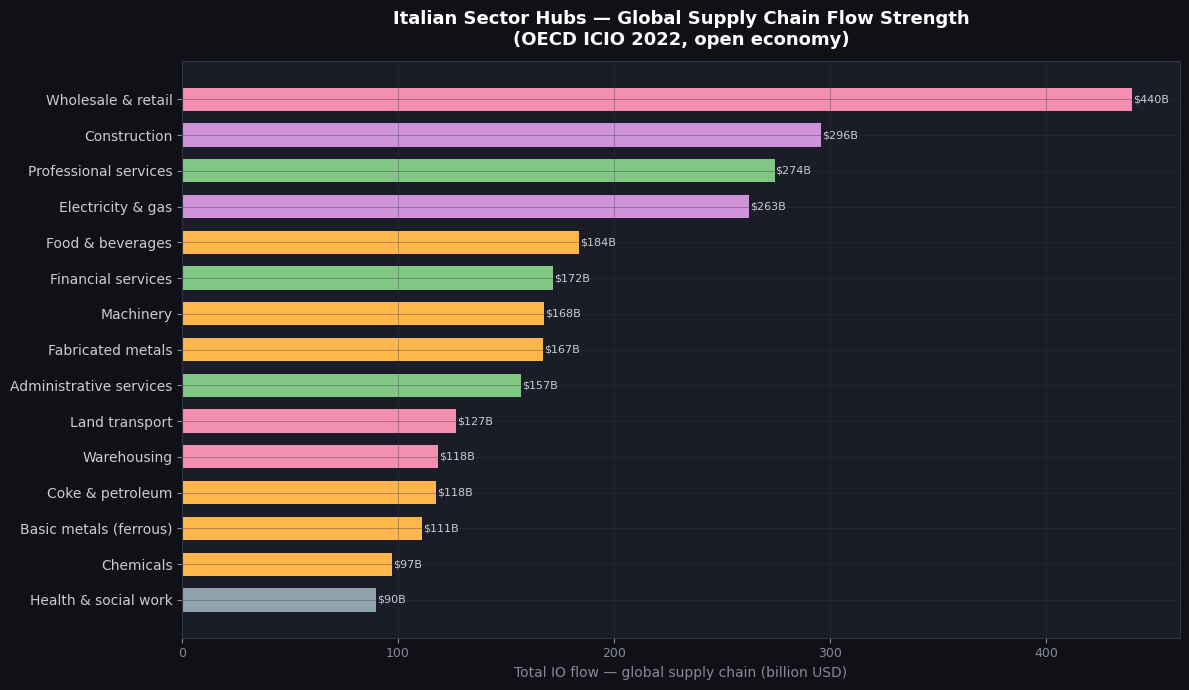

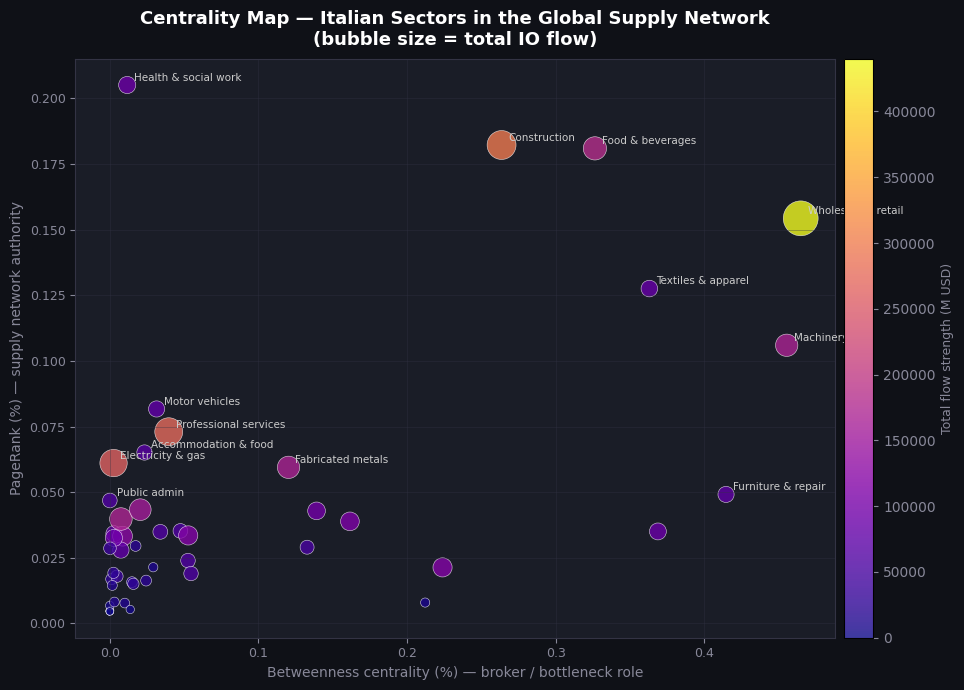

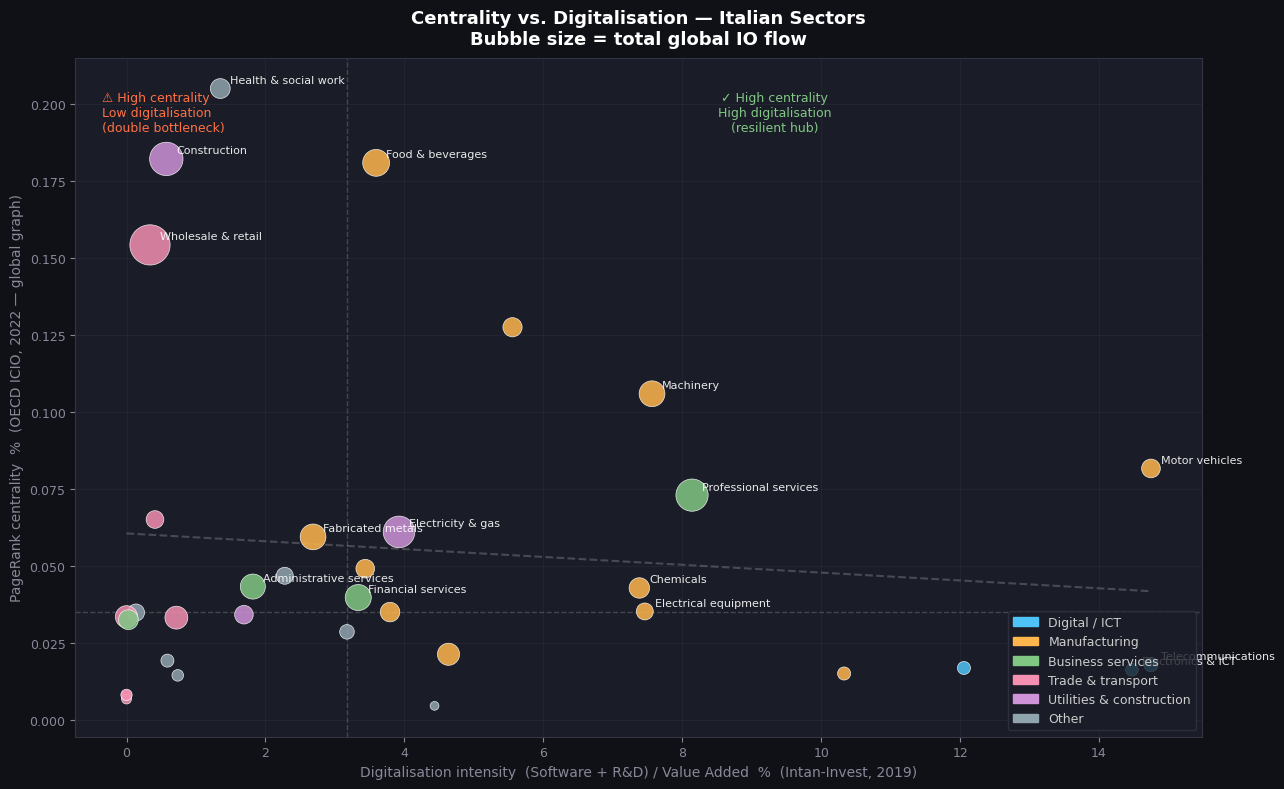

In [12]:
"""
STEP 6 — Visualisations
========================
Depends on: merged, double_risk  (Step 5)

Three figures, each saved separately so you can use them independently
in your presentation.

  fig1 — Hub ranking by total IO flow strength
  fig2 — PageRank vs Betweenness scatter (centrality map)
  fig3 — Centrality vs Digitalisation (the main result)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Shared style ──────────────────────────────────────────────────────────────
BG       = "#0f1117"
PANEL    = "#1a1d27"
GRID     = "#333344"
TEXT     = "#cccccc"
AXIS     = "#888899"

def style_ax(ax):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=AXIS, labelsize=9)
    ax.xaxis.label.set_color(AXIS)
    ax.yaxis.label.set_color(AXIS)
    for spine in ax.spines.values():
        spine.set_color(GRID)
    ax.grid(True, color=GRID, alpha=0.5, linewidth=0.5)

# ── Sector colour helper (for fig3) ──────────────────────────────────────────
def sector_color(s):
    if s in ["J58T60","J61","J62_63","C26"]:
        return "#4FC3F7", "Digital / ICT"
    if s in ["C10T12","C13T15","C16","C17_18","C19","C20","C21","C22",
             "C23","C24A","C24B","C25","C27","C28","C29","C31T33"]:
        return "#FFB74D", "Manufacturing"
    if s in ["K","M","N","L"]:
        return "#81C784", "Business services"
    if s in ["G","H49","H50","H51","H52","H53","I"]:
        return "#F48FB1", "Trade & transport"
    if s in ["D","E","F"]:
        return "#CE93D8", "Utilities & construction"
    return "#90A4AE", "Other"

# =============================================================================
# FIGURE 1 — Hub ranking by total IO flow strength
# =============================================================================
fig1, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
style_ax(ax)

top15 = merged.nlargest(15, "total_strength")
bar_colors = [sector_color(s)[0] for s in top15["sector"]]

bars = ax.barh(range(len(top15)), top15["total_strength"] / 1000,
               color=bar_colors, edgecolor="none", height=0.65)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["label"], fontsize=10, color=TEXT)
ax.set_xlabel("Total IO flow — global supply chain (billion USD)", fontsize=10)
ax.set_title("Italian Sector Hubs — Global Supply Chain Flow Strength\n(OECD ICIO 2022, open economy)",
             fontsize=13, color="white", fontweight="bold", pad=12)
ax.invert_yaxis()

for bar, val in zip(bars, top15["total_strength"] / 1000):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"${val:.0f}B", va="center", color=TEXT, fontsize=8)

plt.tight_layout()
fig1.savefig("fig1_hub_ranking.png", dpi=150, bbox_inches="tight", facecolor=BG)
print("Saved fig1_hub_ranking.png")

# =============================================================================
# FIGURE 2 — PageRank vs Betweenness (centrality map)
# =============================================================================
fig2, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

size = merged["total_strength"] / merged["total_strength"].max() * 600 + 30

sc = ax.scatter(
    merged["betweenness"] * 100,
    merged["pagerank"] * 100,
    s=size, alpha=0.80,
    c=merged["total_strength"], cmap="plasma",
    edgecolors="white", linewidths=0.4
)

# Label high-pagerank sectors
for _, row in merged[merged["pagerank"] >= merged["pagerank"].quantile(0.75)].iterrows():
    ax.annotate(row["label"],
                (row["betweenness"] * 100, row["pagerank"] * 100),
                xytext=(5, 3), textcoords="offset points",
                fontsize=7.5, color=TEXT)

cb = plt.colorbar(sc, ax=ax, pad=0.01)
cb.set_label("Total flow strength (M USD)", color=AXIS, fontsize=9)
cb.ax.yaxis.set_tick_params(color=AXIS)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=AXIS)

ax.set_xlabel("Betweenness centrality (%) — broker / bottleneck role", fontsize=10)
ax.set_ylabel("PageRank (%) — supply network authority", fontsize=10)
ax.set_title("Centrality Map — Italian Sectors in the Global Supply Network\n"
             "(bubble size = total IO flow)",
             fontsize=13, color="white", fontweight="bold", pad=10)

plt.tight_layout()
fig2.savefig("fig2_centrality_map.png", dpi=150, bbox_inches="tight", facecolor=BG)
print("Saved fig2_centrality_map.png")

# =============================================================================
# FIGURE 3 — Centrality vs Digitalisation (main result)
# =============================================================================
plot_df = merged.dropna(subset=["dig_intensity"]).copy()
# Winsorise top 5% to avoid one outlier crushing the x-axis
plot_df["dig_clip"] = plot_df["dig_intensity"].clip(
    upper=plot_df["dig_intensity"].quantile(0.95)
)

fig3, ax = plt.subplots(figsize=(13, 8), facecolor=BG)
style_ax(ax)

clrs = [sector_color(s)[0] for s in plot_df["sector"]]
sz   = plot_df["total_strength"] / plot_df["total_strength"].max() * 800 + 40

ax.scatter(plot_df["dig_clip"] * 100, plot_df["pagerank"] * 100,
           s=sz, c=clrs, alpha=0.85, edgecolors="white", linewidths=0.5, zorder=3)

# Annotate a curated list of interesting sectors
ANNOTATE = ["G","K","M","C28","J62_63","C20","D","F","C26","J61","C27","C25","C10T12","Q","N","C29"]
for _, row in plot_df[plot_df["sector"].isin(ANNOTATE)].iterrows():
    ax.annotate(row["label"],
                xy=(row["dig_clip"] * 100, row["pagerank"] * 100),
                xytext=(7, 4), textcoords="offset points",
                fontsize=8, color="white", alpha=0.9)

# Quadrant lines at medians
med_x = plot_df["dig_clip"].median() * 100
med_y = plot_df["pagerank"].median() * 100
ax.axvline(med_x, color="white", alpha=0.18, linewidth=1, linestyle="--")
ax.axhline(med_y, color="white", alpha=0.18, linewidth=1, linestyle="--")

# Quadrant labels — adjust x/y positions if they overlap your data
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[0] + (med_x - xlim[0]) * 0.1, ylim[1] * 0.95,
        "⚠ High centrality\nLow digitalisation\n(double bottleneck)",
        color="#FF7043", fontsize=9, va="top")
ax.text(med_x + (xlim[1] - med_x) * 0.5, ylim[1] * 0.95,
        "✓ High centrality\nHigh digitalisation\n(resilient hub)",
        color="#81C784", fontsize=9, va="top", ha="center")

# Trend line
x = plot_df["dig_clip"] * 100
y = plot_df["pagerank"] * 100
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, np.poly1d(np.polyfit(x, y, 1))(xline),
        "--", color="white", alpha=0.2, linewidth=1.5)

# Legend
legend_handles = [
    mpatches.Patch(color=c, label=l) for c, l in [
        ("#4FC3F7","Digital / ICT"), ("#FFB74D","Manufacturing"),
        ("#81C784","Business services"), ("#F48FB1","Trade & transport"),
        ("#CE93D8","Utilities & construction"), ("#90A4AE","Other"),
    ]
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9,
          facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)

ax.set_xlabel("Digitalisation intensity  (Software + R&D) / Value Added  %  (Intan-Invest, 2019)",
              fontsize=10)
ax.set_ylabel("PageRank centrality  %  (OECD ICIO, 2022 — global graph)", fontsize=10)
ax.set_title("Centrality vs. Digitalisation — Italian Sectors\n"
             "Bubble size = total global IO flow",
             fontsize=13, color="white", fontweight="bold", pad=10)

plt.tight_layout()
fig3.savefig("fig3_centrality_vs_digitalisation.png",
             dpi=150, bbox_inches="tight", facecolor=BG)
print("Saved fig3_centrality_vs_digitalisation.png")

## (commento generato)

## Results

### Figure 1 — Italian Sector Hubs: Global Supply Chain Flow Strength

The first figure ranks Italian sectors by their total intermediate flow in the global supply network — the sum of all inputs received from and outputs sent to other sectors across all countries in the OECD ICIO table.

**Wholesale & retail trade** dominates by a wide margin at $440B, followed by **Construction** ($296B) and **Professional services** ($274B). These three sectors alone account for a disproportionate share of Italy's domestic supply chain activity. **Electricity & gas** ($263B) and **Food & beverages** ($184B) complete the top five.

A key observation is that the leading sectors are predominantly **services** rather than manufacturing. This is consistent with the structural shift of advanced economies toward service-intensive production, but also reflects the role of services as universal intermediate inputs — virtually every sector purchases wholesale, transport, and professional services, which mechanically inflates their flow strength. Manufacturing sectors (Machinery, Fabricated metals, Chemicals) appear further down the ranking but remain significant.

---

### Figure 2 — Centrality Map: PageRank vs. Betweenness

The second figure plots two complementary centrality measures against each other, with bubble size representing total flow strength. The two axes capture fundamentally different roles in the network:

- **PageRank** (y-axis) measures *supply network authority* — a sector scores high if it is supplied by other systemically important sectors, capturing recursive dependence in the chain.
- **Betweenness centrality** (x-axis) measures *broker role* — the fraction of shortest supply paths that pass through a sector, capturing its potential to disrupt flows if it fails.

**Health & social work** stands out as the highest PageRank sector (≈0.21%) despite near-zero betweenness — it is a major recipient of inputs from across the economy but does not act as a supply chain intermediary. **Construction** and **Food & beverages** occupy a similar high-PageRank position.

The most analytically interesting sectors are those combining moderate-to-high PageRank with elevated betweenness: **Furniture & repair**, **Textiles & apparel**, and **Fabricated metals** show the highest betweenness scores, indicating they act as critical bridges in the supply network. Their disruption would disconnect more supply paths than their raw size would suggest. **Machinery** and **Wholesale & retail** combine high scores on both dimensions, making them the closest candidates to true systemic hubs.

---

### Figure 3 — Centrality vs. Digitalisation: The Main Result

The third figure is the core analytical contribution. It cross-plots PageRank centrality (y-axis, computed on the full global graph) against digitalisation intensity (x-axis, measured as Software & Database investment plus R&D over Value Added from Intan-Invest 2019), with bubble size proportional to total IO flow.

The dashed lines divide the space into four quadrants at the median of each dimension. The quadrant of primary concern is **top-left: high centrality, low digitalisation** — sectors that the production network depends on heavily, but which have not accumulated significant digital capital.

Three sectors stand out in this danger zone:
- **Health & social work** — the most central sector in the network but with near-zero digitalisation intensity, suggesting structural underinvestment in digital infrastructure relative to its systemic importance.
- **Construction** — similarly high centrality with very low digitalisation, consistent with the sector's well-documented resistance to digital adoption across European economies.
- **Wholesale & retail trade** — the largest sector by flow volume sits firmly in the double-bottleneck quadrant, with digitalisation intensity below the median despite being the single most connected node in the Italian supply network.

In contrast, **Motor vehicles**, **Machinery**, and **Professional services** occupy the top-right quadrant — high centrality combined with above-median digitalisation — indicating these sectors are both systemically important and relatively resilient to digital disruption.

The weak negative trend line across the scatter suggests that, on average, more central Italian sectors tend to be *less* digitalised — the opposite of what an efficient digital transition would look like. This is the paper's central finding: Italy's production network bottlenecks and its digitalisation gaps are not randomly distributed but systematically co-located, creating compounded vulnerability.